In [6]:
import os
os.getcwd()

'C:\\Users\\VTB\\TimeSeriesProject\\notebooks'

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14,6)

In [14]:
from pathlib import Path
import pandas as pd

# Корень проекта
PROJECT_ROOT = Path.cwd().parent

# Путь к данным
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("Файл существует:", DATA_PATH.exists())

# Загрузка данных
df = pd.read_csv(DATA_PATH)

# Приведение даты
df["date"] = pd.to_datetime(df["date"])

print("Размер:", df.shape)
print("Колонки:", df.columns.tolist())

PROJECT_ROOT: C:\Users\VTB\TimeSeriesProject
DATA_PATH: C:\Users\VTB\TimeSeriesProject\data\raw\train.csv
Файл существует: True
Размер: (913000, 4)
Колонки: ['date', 'store', 'item', 'sales']


In [16]:
df = pd.read_csv("../data/raw/train.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [12]:
df.describe

<bound method NDFrame.describe of               date  store  item  sales
0       2013-01-01      1     1     13
1       2013-01-02      1     1     11
2       2013-01-03      1     1     14
3       2013-01-04      1     1     13
4       2013-01-05      1     1     10
...            ...    ...   ...    ...
912995  2017-12-27     10    50     63
912996  2017-12-28     10    50     59
912997  2017-12-29     10    50     74
912998  2017-12-30     10    50     62
912999  2017-12-31     10    50     82

[913000 rows x 4 columns]>

In [13]:
#Проверка качества данных
#Пропуски
df.isna().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [14]:
#Дубликаты
df.duplicated().sum()


np.int64(0)

In [15]:
#Смотрим диапазон дат:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].min())
print(df["date"].max())

2013-01-01 00:00:00
2017-12-31 00:00:00


In [18]:
#Количество уникальных магазинов
df["store"].nunique()

10

In [19]:
#Количество уникальных товаров
df["item"].nunique()

50

In [22]:
#Преобразуем данные в ряд
df["unique_id"] = (
    "store_" +
    df["store"].astype(str) +
    "_item_" +
    df["item"].astype(str)
)

In [21]:
#Переименуем колонки
df = df.rename(columns={
    "date": "ds",
    "sales": "y"
})

In [23]:
df = df[["unique_id", "ds", "y"]]

In [24]:
#Новая таблица
df.head

<bound method NDFrame.head of                unique_id         ds   y
0         store_1_item_1 2013-01-01  13
1         store_1_item_1 2013-01-02  11
2         store_1_item_1 2013-01-03  14
3         store_1_item_1 2013-01-04  13
4         store_1_item_1 2013-01-05  10
...                  ...        ...  ..
912995  store_10_item_50 2017-12-27  63
912996  store_10_item_50 2017-12-28  59
912997  store_10_item_50 2017-12-29  74
912998  store_10_item_50 2017-12-30  62
912999  store_10_item_50 2017-12-31  82

[913000 rows x 3 columns]>

In [26]:
#Количество временных рядов
df["unique_id"].nunique()

500

In [27]:
#Визуализация данных на примере нескольких случайных рядов
sample_ids = np.random.choice(
    df["unique_id"].unique(),
    6,
    replace=False
)

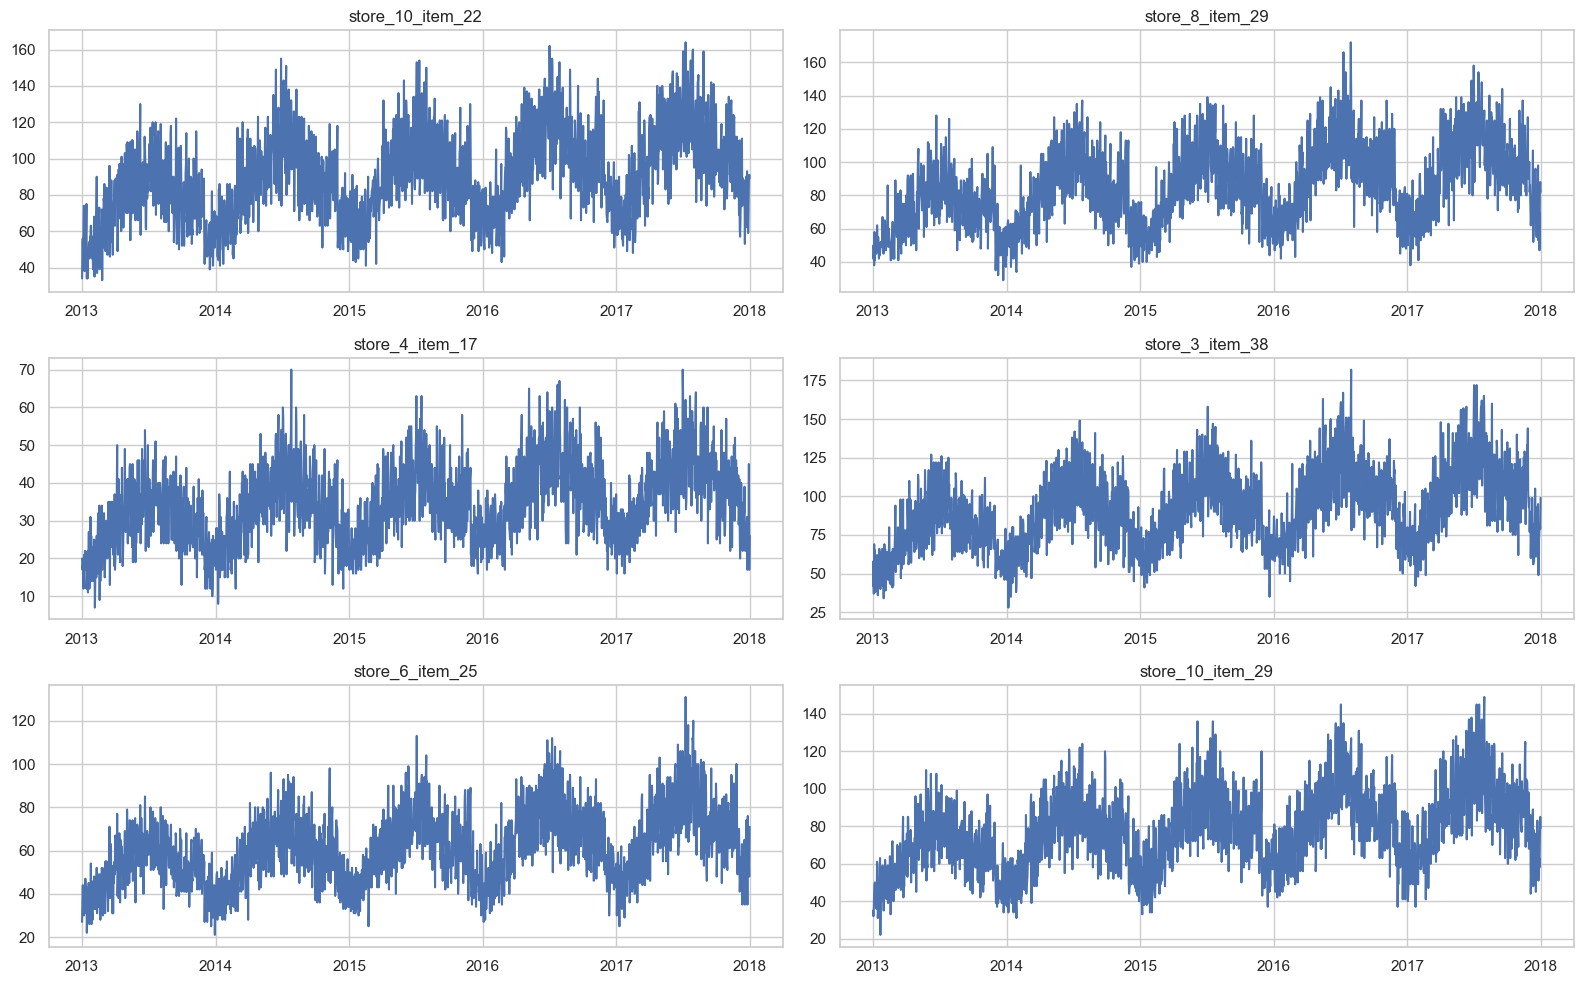

In [28]:
#Графики
fig, axes = plt.subplots(3,2, figsize=(16,10))

for uid, ax in zip(sample_ids, axes.ravel()):

    temp = df[df["unique_id"] == uid]

    ax.plot(temp["ds"], temp["y"])

    ax.set_title(uid)

plt.tight_layout()

<Axes: xlabel='y', ylabel='Count'>

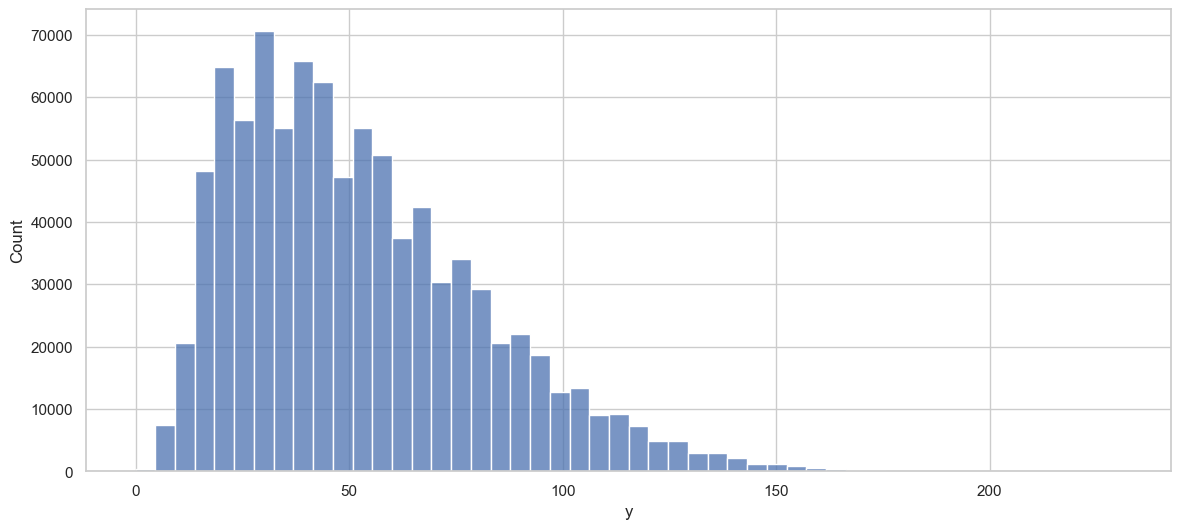

In [29]:
#Распределение продаж
sns.histplot(df["y"], bins=50)

<Axes: xlabel='y'>

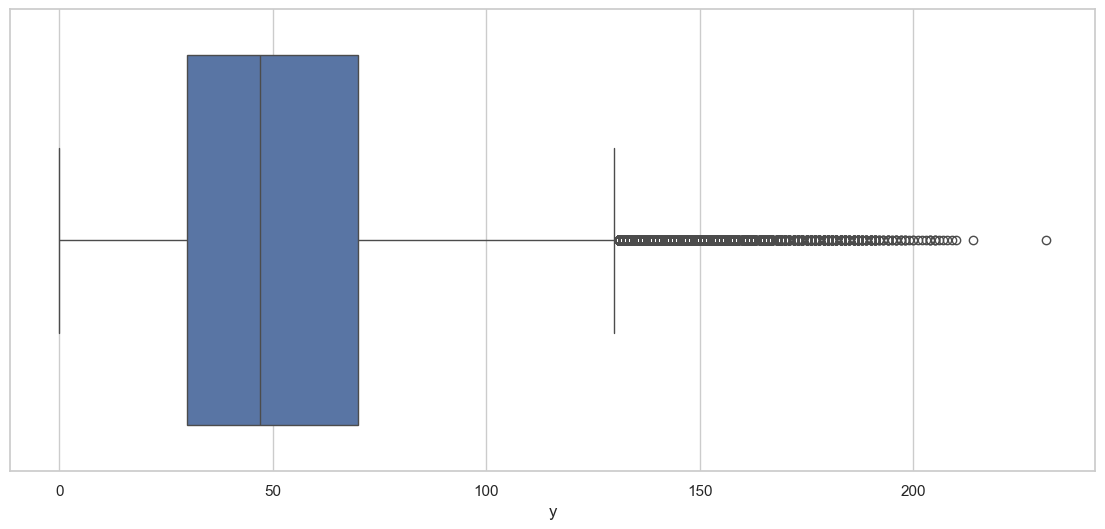

In [30]:
sns.boxplot(x=df["y"])

<Axes: xlabel='month', ylabel='y'>

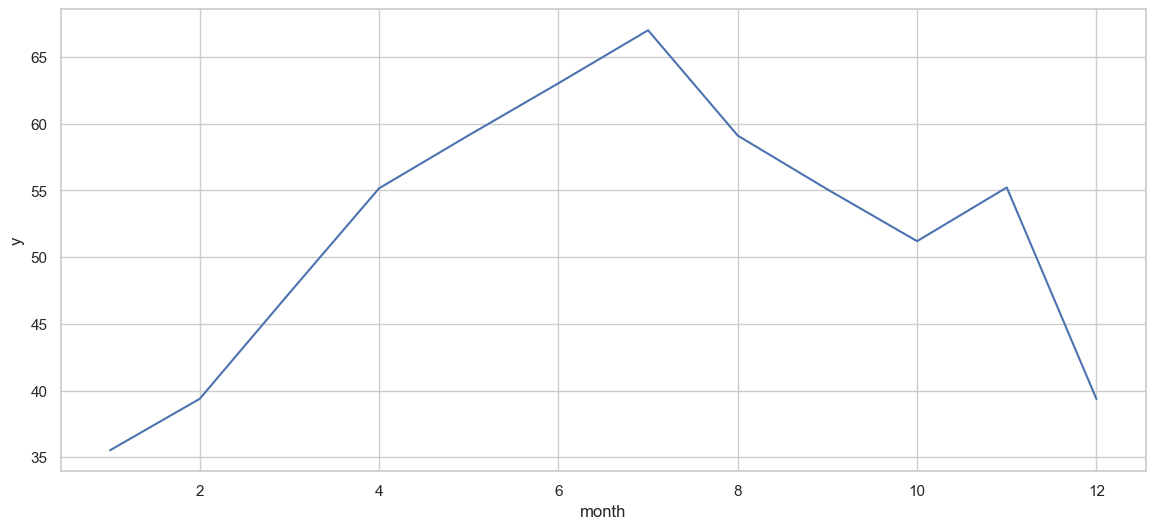

In [31]:
#Средние продажи (по месяцам)
temp = df.copy()

temp["month"] = temp["ds"].dt.month

monthly = (
    temp
    .groupby("month")["y"]
    .mean()
)

sns.lineplot(monthly)

<Axes: xlabel='weekday'>

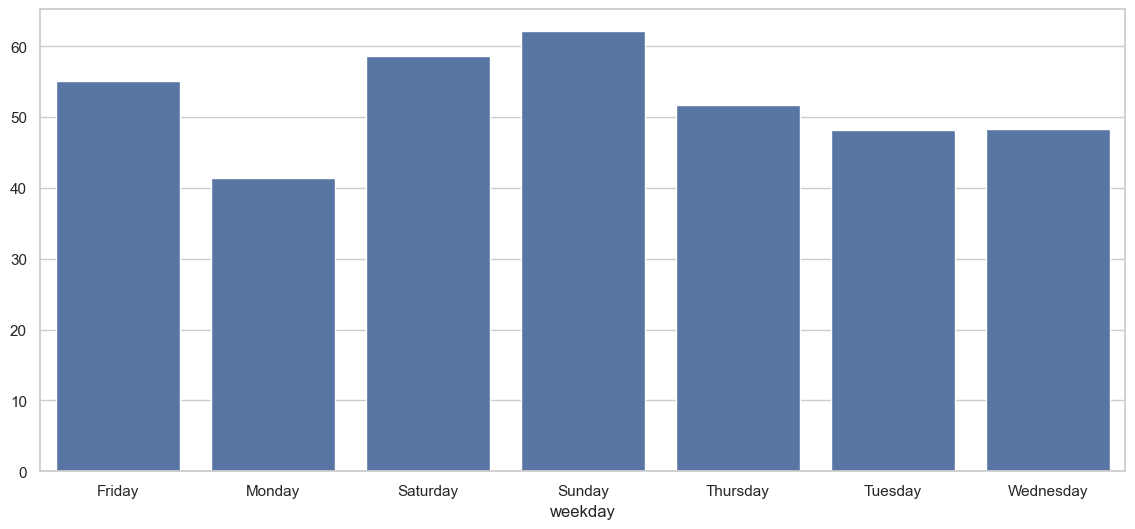

In [32]:
#Средние продажи по дням недели
temp["weekday"] = temp["ds"].dt.day_name()

weekday = (
    temp
    .groupby("weekday")["y"]
    .mean()
)

sns.barplot(
    x=weekday.index,
    y=weekday.values
)

In [33]:
#STL-декомпозиция
series = (
    df[df["unique_id"] == sample_ids[0]]
    .set_index("ds")["y"]
)

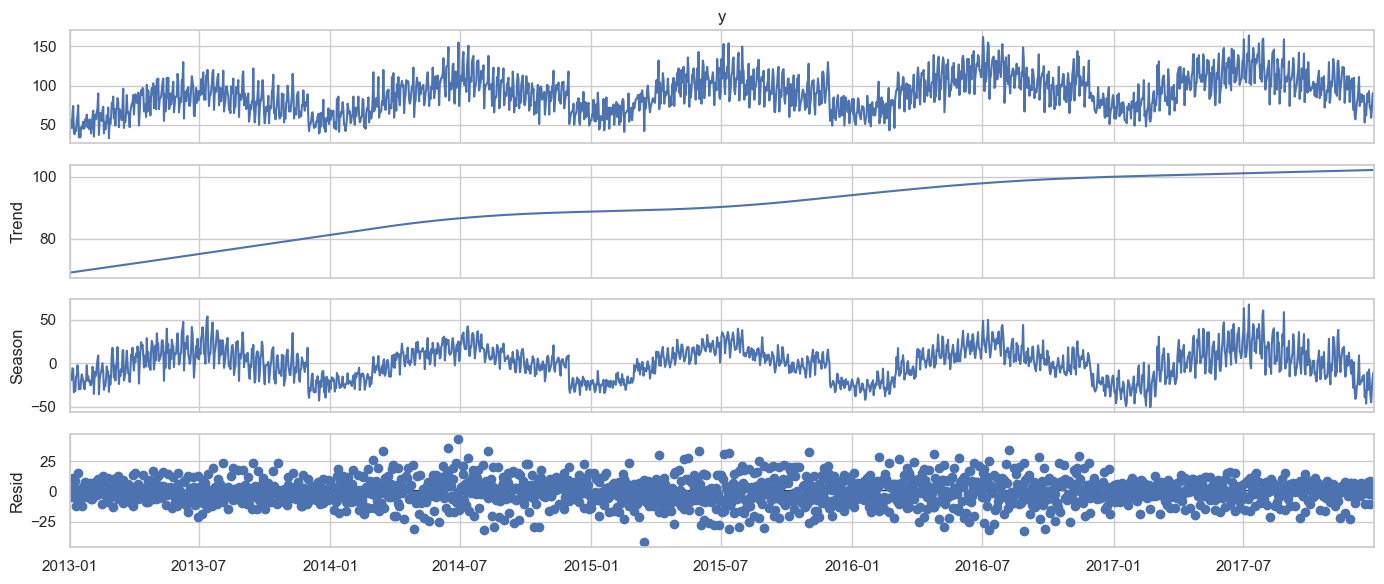

In [34]:
stl = STL(series, period=365)

result = stl.fit()

result.plot();

In [52]:
#Проверка стационарности 
adf_result = adfuller(series.dropna())

print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF statistic: -2.849816769961151
p-value: 0.0515025846226347


In [38]:
#Проверка стационарности KPSS
kpss_result = kpss(series)

print(kpss_result[1])

0.01


C:\Users\VTB\AppData\Local\Temp\ipykernel_7572\1627760652.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series)


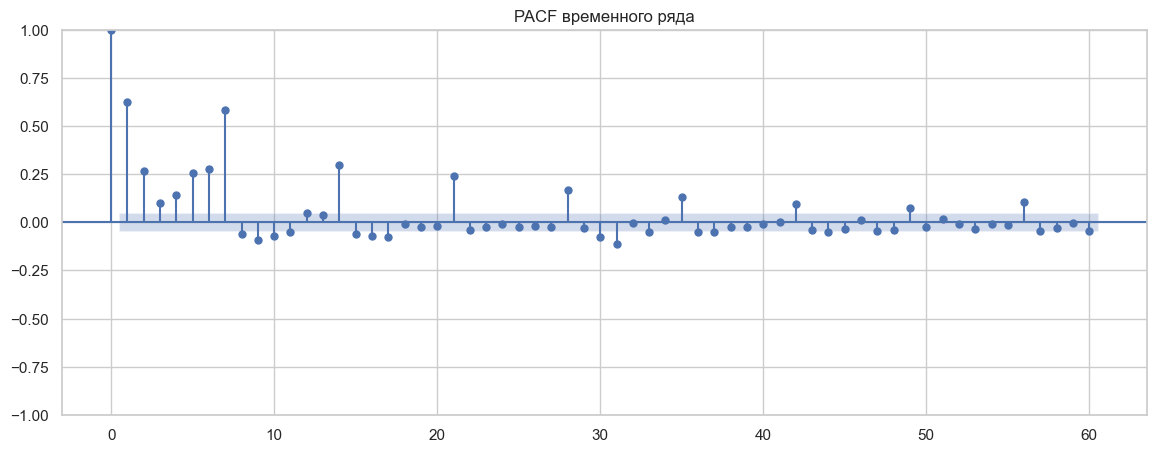

In [42]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_pacf(
    series,
    lags=60,
    ax=ax,
    method="ywm"
)

plt.title(
    "PACF временного ряда"
)

plt.show()

In [43]:
#Разбиваем данные на train / validation / test границах по датам Train (до 2016/07/31), Validation (2016/08/01 ... 2016/10/31, TEST (2016.11.01 ... 2017.01.31) 
max_date = df["date"].max()

test_start = max_date - pd.Timedelta(days=89)

train_df = df[df["date"] < test_start].copy()
test_df = df[df["date"] >= test_start].copy()

print("Train:", train_df["date"].min(), "—", train_df["date"].max())
print("Test :", test_df["date"].min(), "—", test_df["date"].max())

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

KeyError: 'date'

In [44]:
print(df.columns.tolist())
print(df.head())

['unique_id', 'ds', 'y']
        unique_id         ds   y
0  store_1_item_1 2013-01-01  13
1  store_1_item_1 2013-01-02  11
2  store_1_item_1 2013-01-03  14
3  store_1_item_1 2013-01-04  13
4  store_1_item_1 2013-01-05  10


In [45]:
import pandas as pd

DATA_PATH = "../data/raw/train.csv"

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

print(df.shape)
print(df.columns.tolist())

(913000, 4)
['date', 'store', 'item', 'sales']


In [47]:
max_date = df["date"].max()

test_start = max_date - pd.Timedelta(days=89)

train_df = df[df["date"] < test_start].copy()
test_df = df[df["date"] >= test_start].copy()

print("Максимальная дата:", max_date)
print("Начало теста:", test_start)

print("\nTRAIN:")
print(train_df["date"].min(), "—", train_df["date"].max())
print("Строк:", len(train_df))

print("\nTEST:")
print(test_df["date"].min(), "—", test_df["date"].max())
print("Строк:", len(test_df))

Максимальная дата: 2017-12-31 00:00:00
Начало теста: 2017-10-03 00:00:00

TRAIN:
2013-01-01 00:00:00 — 2017-10-02 00:00:00
Строк: 868000

TEST:
2017-10-03 00:00:00 — 2017-12-31 00:00:00
Строк: 45000


In [48]:
max_date = df["date"].max()

test_start = max_date - pd.Timedelta(days=89)
val_start = max_date - pd.Timedelta(days=179)

train_df = df[df["date"] < val_start].copy()

val_df = df[
    (df["date"] >= val_start) &
    (df["date"] < test_start)
].copy()

test_df = df[
    df["date"] >= test_start
].copy()

print("TRAIN:")
print(train_df["date"].min(), "—", train_df["date"].max())
print("Строк:", len(train_df))

print("\nVALIDATION:")
print(val_df["date"].min(), "—", val_df["date"].max())
print("Строк:", len(val_df))

print("\nTEST:")
print(test_df["date"].min(), "—", test_df["date"].max())
print("Строк:", len(test_df))

TRAIN:
2013-01-01 00:00:00 — 2017-07-04 00:00:00
Строк: 823000

VALIDATION:
2017-07-05 00:00:00 — 2017-10-02 00:00:00
Строк: 45000

TEST:
2017-10-03 00:00:00 — 2017-12-31 00:00:00
Строк: 45000


In [49]:
forecast_df = df.copy()

forecast_df["unique_id"] = (
    forecast_df["store"].astype(str)
    + "_"
    + forecast_df["item"].astype(str)
)

forecast_df = forecast_df.rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

forecast_df = forecast_df[
    ["unique_id", "ds", "y"]
].sort_values(
    ["unique_id", "ds"]
)

print(forecast_df.head())
print("Количество рядов:", forecast_df["unique_id"].nunique())

      unique_id         ds   y
16434      10_1 2013-01-01  14
16435      10_1 2013-01-02  14
16436      10_1 2013-01-03  16
16437      10_1 2013-01-04  17
16438      10_1 2013-01-05  12
Количество рядов: 500


In [50]:
print("Количество временных рядов:",
      forecast_df["unique_id"].nunique())

print("Количество наблюдений:",
      len(forecast_df))

Количество временных рядов: 500
Количество наблюдений: 913000


In [51]:
#Сохраняем подготовленные данные
OUTPUT_PATH = "../data/processed/sales_prepared.csv"

forecast_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Данные сохранены: {OUTPUT_PATH}")

Данные сохранены: ../data/processed/sales_prepared.csv


In [ ]:
#Выводы по EDA
1. Описание временного ряда
В работе исследуется временной ряд ежедневных продаж товаров в магазинах на примере набора данных Store Item Demand Forecasting Challenge, содержащий 913 000 наблюдений и четыре исходных признака: дата продажи (date), в каком магазине (store), товар (item) и сколько продано (sales).

В наборе данных представлены 10 магазинов и 50 товаров. Таким образом, данные содержат 500 комбинаций «магазин–товар», каждая из которых рассматривается как отдельный временной ряд.

2. Постановка задачи
Цель исследования — построение и сравнение методов прогнозирования ежедневных продаж товаров в магазинах.
Для каждой комбинации store × item требуется прогнозировать будущие значения переменной sales на заданном горизонте прогнозирования.

В качестве основного горизонта прогнозирования выбран период 14 дней. Такой горизонт позволяет оценить способность моделей учитывать краткосрочную динамику и недельную сезонность.

Исследование включает классические статистические методы прогнозирования, методы машинного обучения и методы глубокого обучения.

Основными критериями сравнения моделей являются MAE, RMSE, sMAPE и MASE. Дополнительно анализируется время обучения и формирования прогноза.

3. Подготовка данных
На этапе предварительной обработки выполнены:
проверка структуры набора данных;
проверка типов данных;
преобразование date в формат datetime;
проверка пропущенных значений;
проверка дубликатов;
проверка уникальности комбинаций date × store × item;
анализ количества магазинов и товаров;
проверка полноты временных рядов;
сортировка наблюдений по времени.
Для дальнейшей работы данные преобразованы в формат unique_id, ds, y, используемый библиотеками прогнозирования временных рядов.
Поле unique_id формируется как комбинация идентификатора магазина и товара.

4. EDA
Предварительный анализ показал, что набор данных представляет собой панель из 500 связанных временных рядов. Для каждого ряда наблюдается ежедневная динамика продаж.
В ходе EDA получено:

а) общий тренд продаж - повышательный год от года, 
б) недельная сезонность - присутствует сезонность в летний месяца (сопровождается увеличением объема продаж);
в) месячная и годовая динамика;
г) автокорреляция - отсутствует;
д) стационарность - с учетом полученных значений по  ADF и KPSs гипотеза о стационарности отвергается, исхождный ярд не стационарен;
е) компоненты тренда, сезонности и остатка.
Особое внимание уделяется недельной сезонности, поскольку продажи могут существенно различаться в зависимости от дня недели. Для её исследования используются группировка по дням недели, ACF и STL-декомпозиция с сезонным периодом 7.
5. Структура задачи прогнозирования
Исходные данные не рассматриваются как один независимый временной ряд. Каждая пара store × item формирует отдельный временной ряд, однако при использовании глобальных моделей информация всех 500 рядов может использоваться совместно.
Такой подход позволяет в дальнейшем сравнить локальные статистические методы с глобальными ML и DL моделями.

Для оценки качества моделей данные разделяются хронологически. Случайное перемешивание наблюдений не используется, поскольку оно приводит к утечке информации из будущего в прошлое.



